In [8]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/StudentsPerformance.csv")

df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
      .str.replace("-", "_")
)

def find_column(columns, options):
    for opt in options:
        if opt in columns:
            return opt
    raise ValueError(f"Expected one of {options}, but got {list(columns)}")

math_col    = find_column(df.columns, ["math_score", "maths_score", "math"])
reading_col = find_column(df.columns, ["reading_score", "reading"])
writing_col = find_column(df.columns, ["writing_score", "writing"])
gender_col  = find_column(df.columns, ["gender", "sex"])
lunch_col   = find_column(df.columns, ["lunch", "lunch_type"])
test_col    = find_column(df.columns, ["test_preparation_course", "test_prep"])

score_cols = [math_col, reading_col, writing_col]

df[score_cols] = df[score_cols].apply(pd.to_numeric, errors="coerce")

grouped = df.groupby([gender_col, lunch_col, test_col])
for col in score_cols:
    df[col] = df[col].fillna(grouped[col].transform("median"))
    df[col] = df[col].fillna(df[col].median())

cleaned_file = "/content/StudentsPerformance_cleaned.csv"
df.to_csv(cleaned_file, index=False)

FIG_SIZE = (800/100, 600/100)
DPI_SAVE = 300

out_dir = "/content/question_2/Result"
os.makedirs(out_dir, exist_ok=True)

/tmp/ipython-input-3242690668.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  elements = plt.boxplot(plot_values, labels=plot_names,


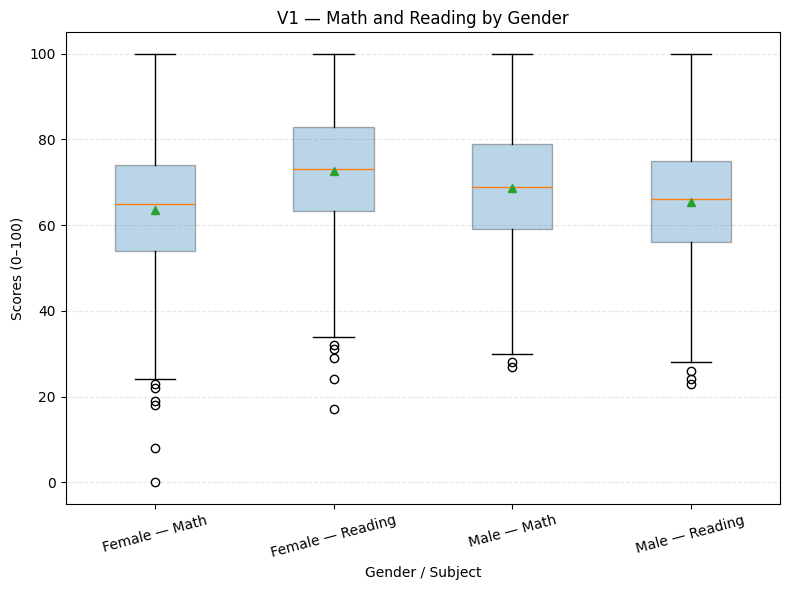

Saved plot to: /content/question_2/Result/V1_gender_boxplots.png


In [6]:
plt.figure(figsize=FIG_SIZE)

plot_values, plot_names = [], []
for group in df[gender_col].dropna().unique():
    part = df[df[gender_col] == group]
    plot_values += [part[math_col].to_numpy(), part[reading_col].to_numpy()]
    plot_names += [f"{group.capitalize()} — Math", f"{group.capitalize()} — Reading"]

elements = plt.boxplot(plot_values, labels=plot_names,
                       patch_artist=True, showmeans=True)

for box in elements["boxes"]:
    box.set(alpha=0.3)

plt.title("V1 — Math and Reading by Gender")
plt.xlabel("Gender / Subject")
plt.ylabel("Scores (0–100)")
plt.xticks(rotation=15)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()

output_file = os.path.join(out_dir, "V1_gender_boxplots.png")
plt.savefig(output_file, dpi=DPI_SAVE)
plt.show()

print("Saved plot to:", output_file)

/tmp/ipython-input-788296122.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, x=test_col, y=math_col,


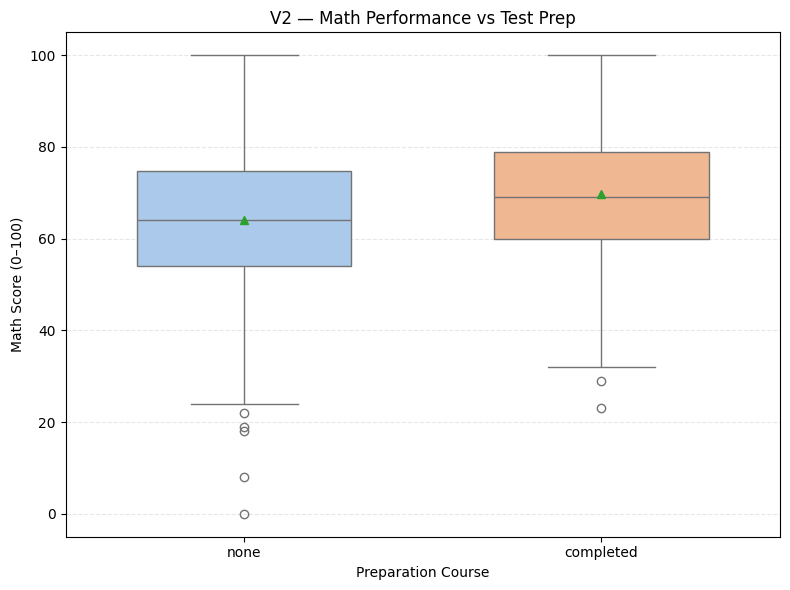

Saved V2 figure to: /content/question_2/Result/V2_test_prep_math.png


In [7]:


plt.figure(figsize=(8, 6))
ax = sns.boxplot(data=df, x=test_col, y=math_col,
                 hue=None, palette="pastel", showcaps=True,
                 showmeans=True, width=0.6)

ax.set_title("V2 — Math Performance vs Test Prep", fontsize=12)
ax.set_xlabel("Preparation Course", fontsize=10)
ax.set_ylabel("Math Score (0–100)", fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
out_path = os.path.join(out_dir, "V2_test_prep_math.png")
plt.savefig(out_path, dpi=300)
plt.show()

print("Saved V2 figure to:", out_path)

/tmp/ipython-input-107735978.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=lunch_means, x=lunch_col, y="overall_avg",


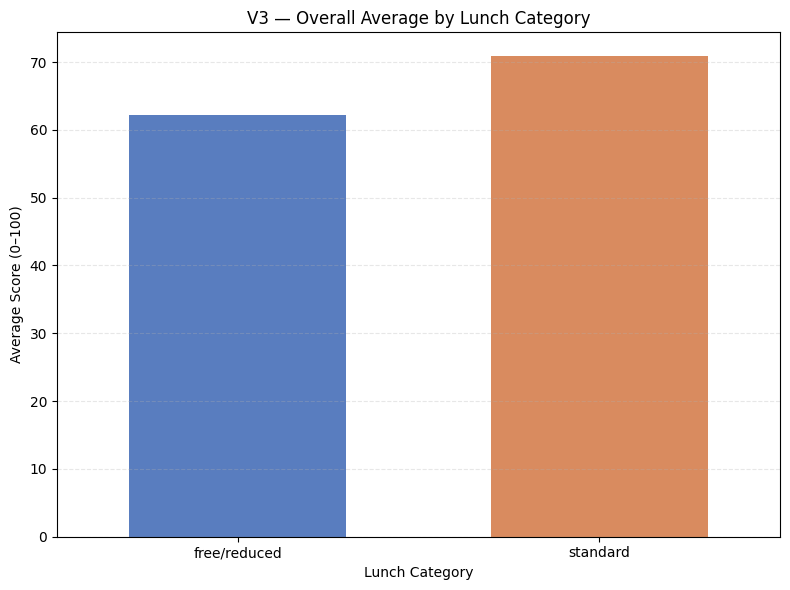

Saved V3 figure to: /content/question_2/Result/V3_lunch_avg.png


In [9]:

df["overall_avg"] = df[score_cols].mean(axis=1)
lunch_means = df.groupby(lunch_col, as_index=False)["overall_avg"].mean()

plt.figure(figsize=(8, 6))
ax = sns.barplot(data=lunch_means, x=lunch_col, y="overall_avg",
                 palette="muted", width=0.6)

ax.set_title("V3 — Overall Average by Lunch Category", fontsize=12)
ax.set_xlabel("Lunch Category", fontsize=10)
ax.set_ylabel("Average Score (0–100)", fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
out_path = os.path.join(out_dir, "V3_lunch_avg.png")
plt.savefig(out_path, dpi=300)
plt.show()

print("Saved V3 figure to:", out_path)

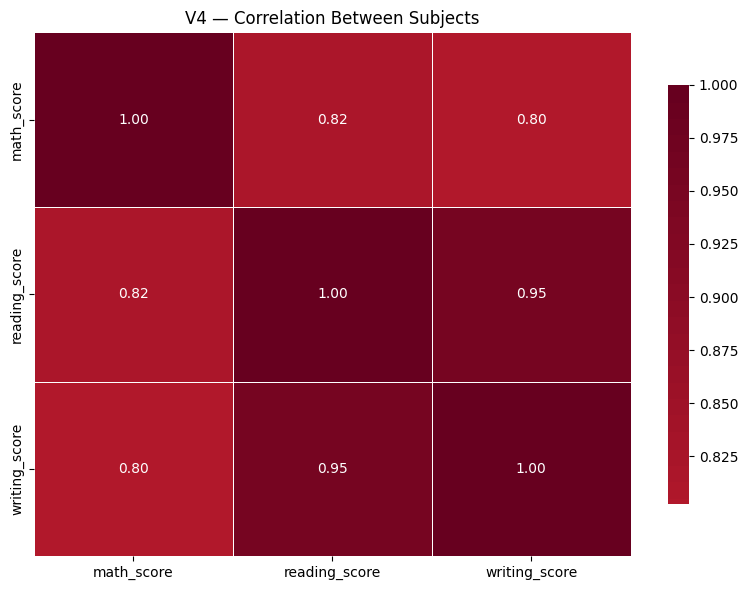

Saved V4 figure to: /content/question_2/Result/V4_subject_correlation.png


In [10]:
corr_matrix = df[score_cols].corr()

plt.figure(figsize=(8, 6))
ax = sns.heatmap(corr_matrix, annot=True, fmt=".2f",
                 cmap="RdBu_r", center=0, linewidths=0.5,
                 cbar_kws={"shrink": 0.8})

ax.set_title("V4 — Correlation Between Subjects", fontsize=12)

plt.tight_layout()
out_path = os.path.join(out_dir, "V4_subject_correlation.png")
plt.savefig(out_path, dpi=300)
plt.show()

print("Saved V4 figure to:", out_path)

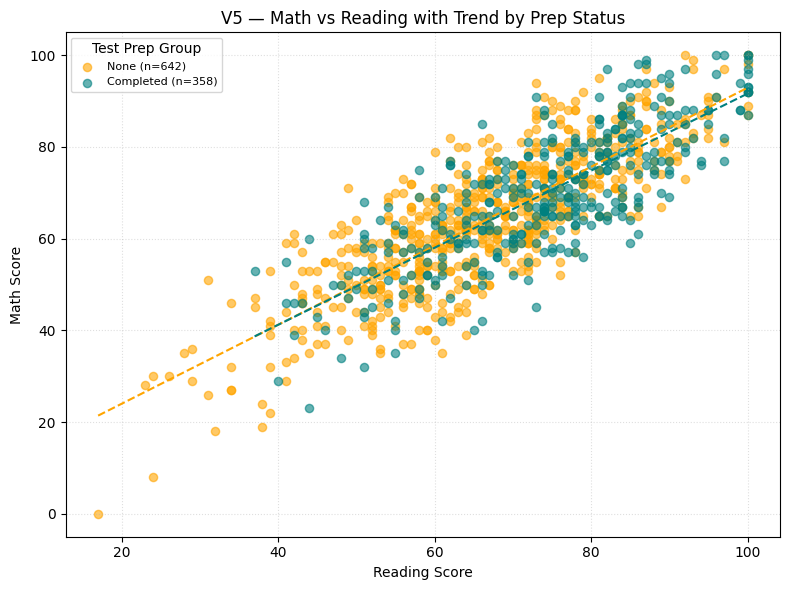

Saved V5 figure to: /content/question_2/Result/V5_math_reading_trend.png


In [11]:
palette = {"completed": "teal", "none": "orange"}

plt.figure(figsize=(8, 6))
for group in df[test_col].dropna().unique():
    subset = df[df[test_col] == group]
    plt.scatter(subset[reading_col], subset[math_col],
                alpha=0.6, s=35, color=palette.get(group, "gray"),
                label=f"{group.capitalize()} (n={len(subset)})")

    coeffs = np.polyfit(subset[reading_col], subset[math_col], deg=1)
    x_vals = np.linspace(subset[reading_col].min(), subset[reading_col].max(), 100)
    y_vals = np.polyval(coeffs, x_vals)
    plt.plot(x_vals, y_vals, linestyle="--", color=palette.get(group, "gray"))

plt.title("V5 — Math vs Reading with Trend by Prep Status", fontsize=12)
plt.xlabel("Reading Score", fontsize=10)
plt.ylabel("Math Score", fontsize=10)
plt.legend(title="Test Prep Group", fontsize=8)
plt.grid(axis="both", linestyle=":", alpha=0.4)
plt.tight_layout()

out_path = os.path.join(out_dir, "V5_math_reading_trend.png")
plt.savefig(out_path, dpi=300)
plt.show()

print("Saved V5 figure to:", out_path)